<a href="https://colab.research.google.com/github/springboardmentor891v/CreditPathAI/blob/Vaibhavi/Microsoft_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


In [ ]:
# Load the dataset
df_loan = pd.read_csv('/content/drive/MyDrive/CreditPathAI/Loan.txt', sep='\t')
df_borrower = pd.read_csv('/content/drive/MyDrive/CreditPathAI/Borrower.txt', sep='\t')
print("Dataset loaded successfully!")

df = pd.merge(df_borrower, df_loan, on='memberId', how='inner')

print("Merged DataFrame (first 5 rows):")
display(df.head())

print("\nMerged DataFrame Info:")
df.info()

print("\nShape of the merged DataFrame:")
print(df.shape)

Dataset loaded successfully!
Merged DataFrame (first 5 rows):


,memberId,residentialState,yearsEmployment,homeOwnership,annualIncome,incomeVerified,dtiRatio,lengthCreditHistory,numTotalCreditLines,numOpenCreditLines,...,loanId,date,purpose,isJointApplication,loanAmount,term,interestRate,monthlyPayment,grade,loanStatus
0,2305095,NM,10+ years,rent,56471,1,16.80,6,11,9.0,...,1888978,12/10/2014,debtconsolidation,0.0,25190.0,60 months,6.25,490,E3,Current
1,2610493,WA,2-5 years,rent,55038,0,19.99,22,8,7.0,...,1299695,9/15/2014,debtconsolidation,0.0,21189.0,60 months,10.49,455,B3,Current
2,2491679,MS,< 1 year,rent,56610,1,14.33,5,8,5.0,...,1875016,9/11/2014,debtconsolidation,0.0,29908.0,60 months,9.11,622,B2,Current
3,2092798,TX,6-9 years,own,54887,1,14.80,12,14,7.0,...,1440478,4/22/2016,homeimprovement,0.0,13053.0,48 months,11.89,343,B3,Current
4,2633077,MA,2-5 years,rent,53522,1,10.14,4,21,19.0,...,1124634,2/3/2016,debtconsolidation,0.0,24613.0,60 months,15.13,587,A3,Current



Merged DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 27 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   memberId                  100000 non-null  int64  
 1   residentialState          100000 non-null  object 
 2   yearsEmployment           100000 non-null  object 
 3   homeOwnership             100000 non-null  object 
 4   annualIncome              100000 non-null  int64  
 5   incomeVerified            100000 non-null  int64  
 6   dtiRatio                  100000 non-null  float64
 7   lengthCreditHistory       100000 non-null  int64  
 8   numTotalCreditLines       100000 non-null  int64  
 9   numOpenCreditLines        99033 non-null   float64
 10  numOpenCreditLines1Year   100000 non-null  int64  
 11  revolvingBalance          100000 non-null  int64  
 12  revolvingUtilizationRate  100000 non-null  float64
 13  numDerogatoryRec     

In [27]:
#Drop unnecessary columns
# df.drop(['memberId', 'loanId'], axis=1, inplace=True) # This line caused the error
print("Columns after dropping 'memberId' and 'loanId':")
display(df.columns)

Columns after dropping 'memberId' and 'loanId':


Index(['annualIncome', 'incomeVerified', 'dtiRatio', 'lengthCreditHistory',
       'numTotalCreditLines', 'numOpenCreditLines', 'numOpenCreditLines1Year',
       'revolvingBalance', 'revolvingUtilizationRate', 'numDerogatoryRec',
       ...
       'grade_C1', 'grade_C2', 'grade_C3', 'grade_D1', 'grade_D2', 'grade_D3',
       'grade_E1', 'grade_E2', 'grade_E3', 'loanStatus_Default'],
      dtype='object', length=874)

In [ ]:
# Missing values per column
print("Missing values:\n", df.isnull().sum())


Missing values:
 residentialState               0
yearsEmployment                0
homeOwnership                  0
annualIncome                   0
incomeVerified                 0
dtiRatio                       0
lengthCreditHistory            0
numTotalCreditLines            0
numOpenCreditLines           967
numOpenCreditLines1Year        0
revolvingBalance               0
revolvingUtilizationRate       0
numDerogatoryRec               0
numDelinquency2Years           0
numChargeoff1year              0
numInquiries6Mon               0
date                           0
purpose                        0
isJointApplication           971
loanAmount                  1006
term                        1071
interestRate                   0
monthlyPayment                 0
grade                          0
loanStatus                     0
dtype: int64


In [ ]:
#drop columns
df.drop(['memberId', 'loanId'], axis=1, inplace=True)
print("Columns after dropping 'memberId' and 'loanId':")
display(df.columns)

In [ ]:
df.isnull().sum()

,0
residentialState,0
yearsEmployment,0
homeOwnership,0
annualIncome,0
incomeVerified,0
dtiRatio,0
lengthCreditHistory,0
numTotalCreditLines,0
numOpenCreditLines,0
numOpenCreditLines1Year,0


In [ ]:
for col in df.columns:
  print(f" {col}, ----- {df[col].dtype}")

 residentialState, ----- object
 yearsEmployment, ----- object
 homeOwnership, ----- object
 annualIncome, ----- int64
 incomeVerified, ----- int64
 dtiRatio, ----- float64
 lengthCreditHistory, ----- int64
 numTotalCreditLines, ----- int64
 numOpenCreditLines, ----- float64
 numOpenCreditLines1Year, ----- int64
 revolvingBalance, ----- int64
 revolvingUtilizationRate, ----- float64
 numDerogatoryRec, ----- int64
 numDelinquency2Years, ----- int64
 numChargeoff1year, ----- int64
 numInquiries6Mon, ----- int64
 date, ----- object
 purpose, ----- object
 isJointApplication, ----- float64
 loanAmount, ----- float64
 term, ----- object
 interestRate, ----- float64
 monthlyPayment, ----- int64
 grade, ----- object
 loanStatus, ----- object
 isBad, ----- int64


Number of Rows (Loans): 100000
Number of Columns (Features): 26

Summary of numerical columns:


,annualIncome,incomeVerified,dtiRatio,lengthCreditHistory,numTotalCreditLines,numOpenCreditLines,numOpenCreditLines1Year,revolvingBalance,revolvingUtilizationRate,numDerogatoryRec,numDelinquency2Years,numChargeoff1year,numInquiries6Mon,isJointApplication,loanAmount,interestRate,monthlyPayment,isBad
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,54718.013140,0.686070,17.281603,10.922280,15.015820,11.27178,7.604960,14848.970210,65.090856,0.844460,1.613390,1.236130,1.457470,0.049680,20657.935830,10.977798,552.448620,0.100040
std,3178.627286,0.464091,5.100633,10.673098,4.007494,3.75213,3.407668,2507.838336,15.286859,2.519157,4.062456,3.120854,3.303967,0.217284,4707.703905,3.904456,165.072058,0.300055
min,38328.000000,0.000000,0.000000,1.000000,1.000000,1.00000,1.000000,4291.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1618.000000,4.020000,42.000000,0.000000
25%,52648.000000,0.000000,13.820000,4.000000,12.000000,9.00000,5.000000,13150.000000,54.520000,0.000000,0.000000,0.000000,0.000000,0.000000,17517.000000,7.980000,434.000000,0.000000
50%,54781.000000,1.000000,17.240000,6.000000,15.000000,11.00000,7.000000,14852.000000,65.180000,0.000000,0.000000,0.000000,0.000000,0.000000,20600.000000,10.460000,534.000000,0.000000
75%,56866.000000,1.000000,20.720000,15.000000,18.000000,14.00000,10.000000,16537.250000,75.570000,0.000000,1.000000,1.000000,1.000000,0.000000,23750.000000,13.440000,655.000000,0.000000
max,69553.000000,1.000000,40.510000,40.000000,32.000000,29.00000,26.000000,25802.000000,100.000000,15.000000,20.000000,20.000000,19.000000,1.000000,42403.000000,31.700000,1575.000000,1.000000


/tmp/ipython-input-654644573.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="isBad", data=df, palette="Set2")


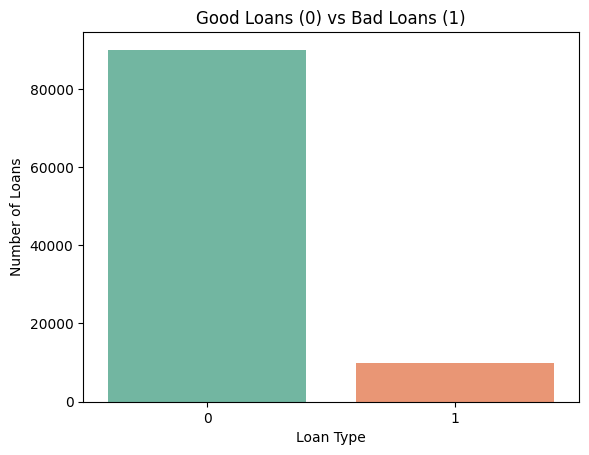

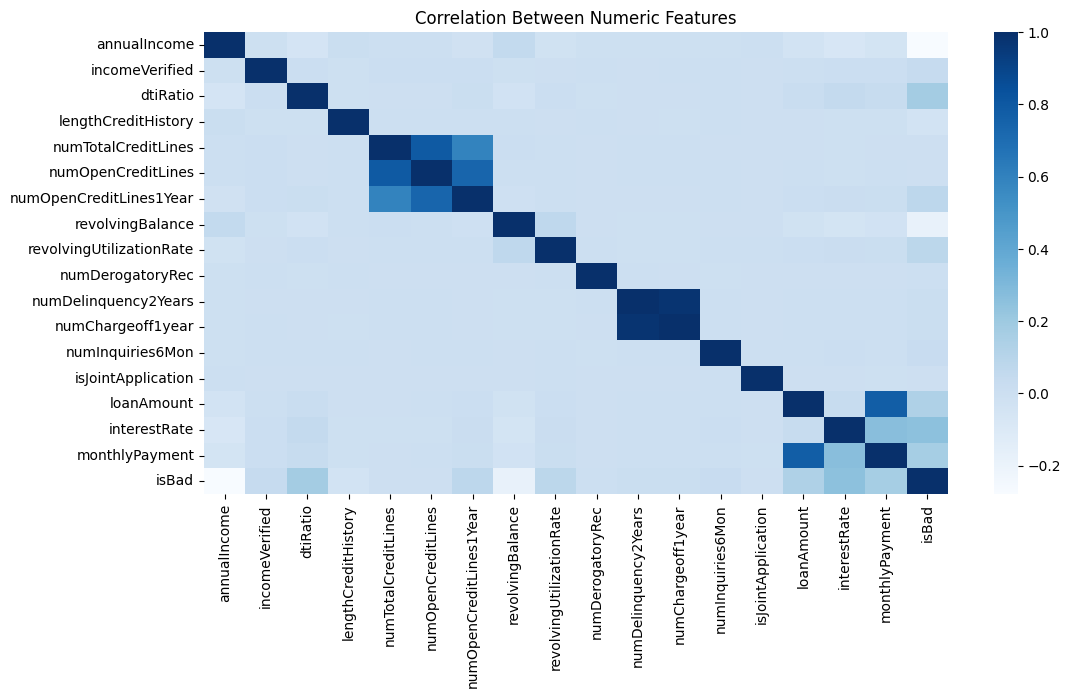

/tmp/ipython-input-654644573.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="isBad", y="annualIncome", data=df, palette="Set3")


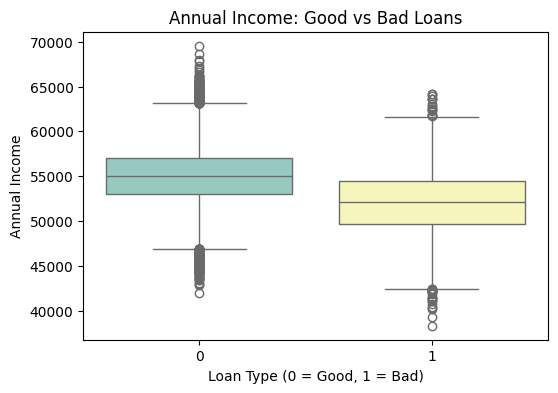

In [ ]:
#Exploratory Data Analysis (EDA)

#  Check overall dataset shape
print("Number of Rows (Loans):", df.shape[0])
print("Number of Columns (Features):", df.shape[1])

# Check summary statistics
print("\nSummary of numerical columns:")
display(df.describe())

# Target variable distribution
sns.countplot(x="isBad", data=df, palette="Set2")
plt.title("Good Loans (0) vs Bad Loans (1)")
plt.xlabel("Loan Type")
plt.ylabel("Number of Loans")
plt.show()

# Correlation heatmap (only numbers)
plt.figure(figsize=(12,6))
# Select only numeric columns for correlation calculation
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), cmap="Blues", annot=False)
plt.title("Correlation Between Numeric Features")
plt.show()

#Example feature vs target
plt.figure(figsize=(6,4))
sns.boxplot(x="isBad", y="annualIncome", data=df, palette="Set3")
plt.title("Annual Income: Good vs Bad Loans")
plt.xlabel("Loan Type (0 = Good, 1 = Bad)")
plt.ylabel("Annual Income")
plt.show()

In [ ]:
#Handle Outliers

def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[column] = np.where(df[column] > upper, upper,
                          np.where(df[column] < lower, lower, df[column]))

# Apply to key numeric features
for col in ["annualIncome", "loanAmount", "debtToIncome"]:
    if col in df.columns:
        remove_outliers(df, col)

print("✅ Outliers capped using IQR method!")


✅ Outliers capped using IQR method!


In [ ]:
# Step 5: Encode categorical variables

df = pd.get_dummies(df, drop_first=True)

print("✅ Categorical features converted into numbers (one-hot encoding)")
print("Updated shape:", df.shape)


✅ Categorical features converted into numbers (one-hot encoding)
Updated shape: (100000, 874)


In [ ]:
# Split into Train & Test

# Drop only 'isBad'
X = df.drop(["isBad"], axis=1)
y = df["isBad"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

# Handle class imbalance with SMOTE
sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)

print("✅ Applied SMOTE. Training set balanced now!")
print(y_train.value_counts())


Training set size: (70000, 873)
Testing set size: (30000, 873)
✅ Applied SMOTE. Training set balanced now!
isBad
0    62997
1    62997
Name: count, dtype: int64


In [ ]:
# Feature Scaling

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Features scaled successfully!")


✅ Features scaled successfully!


In [ ]:
# Initialize the models
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Extra Trees": ExtraTreesClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "XGBoost": XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    "LightGBM": LGBMClassifier(random_state=42),
}

# Train and evaluate each model
for name, model in models.items():
    print(f"\n--- Training {name} ---")
    # Train the model on the resampled training data
    model.fit(X_train_scaled, y_train)
    print(f"{name} trained successfully.")


--- Training Logistic Regression ---
Logistic Regression trained successfully.

--- Training Decision Tree ---
Decision Tree trained successfully.

--- Training Random Forest ---
Random Forest trained successfully.

--- Training Extra Trees ---
Extra Trees trained successfully.

--- Training Gradient Boosting ---
Gradient Boosting trained successfully.

--- Training K-Nearest Neighbors ---
K-Nearest Neighbors trained successfully.

--- Training Naive Bayes ---
Naive Bayes trained successfully.

--- Training XGBoost ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [17:37:38] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost trained successfully.

--- Training LightGBM ---
[LightGBM] [Info] Number of positive: 62997, number of negative: 62997
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.991567 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5048
[LightGBM] [Info] Number of data points in the train set: 125994, number of used features: 873
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best


--- Evaluation for Logistic Regression ---
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     26999
           1       1.00      1.00      1.00      3001

    accuracy                           1.00     30000
   macro avg       1.00      1.00      1.00     30000
weighted avg       1.00      1.00      1.00     30000

ROC-AUC Score: 1.0000


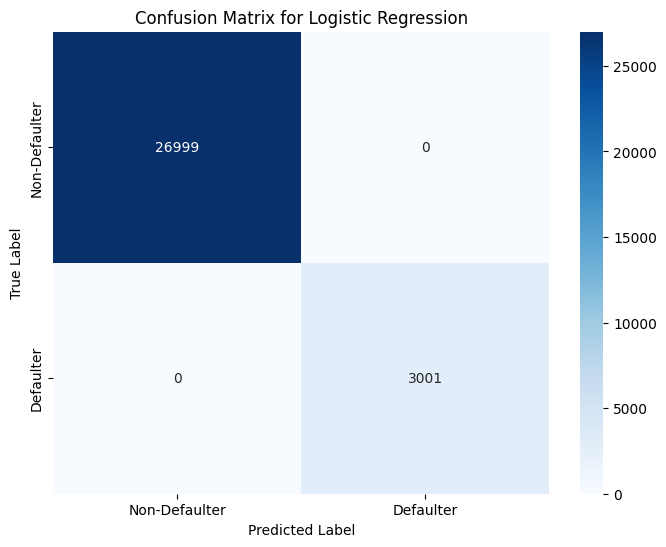


--- Evaluation for Decision Tree ---
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     26999
           1       1.00      1.00      1.00      3001

    accuracy                           1.00     30000
   macro avg       1.00      1.00      1.00     30000
weighted avg       1.00      1.00      1.00     30000

ROC-AUC Score: 1.0000


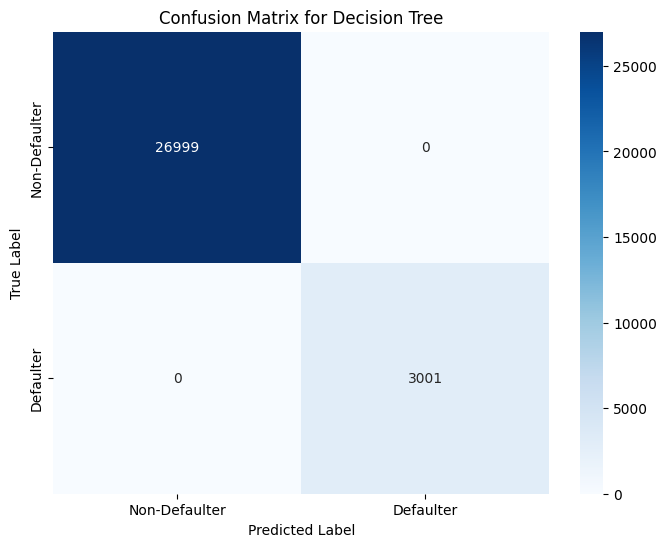


--- Evaluation for Random Forest ---
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     26999
           1       1.00      1.00      1.00      3001

    accuracy                           1.00     30000
   macro avg       1.00      1.00      1.00     30000
weighted avg       1.00      1.00      1.00     30000

ROC-AUC Score: 1.0000


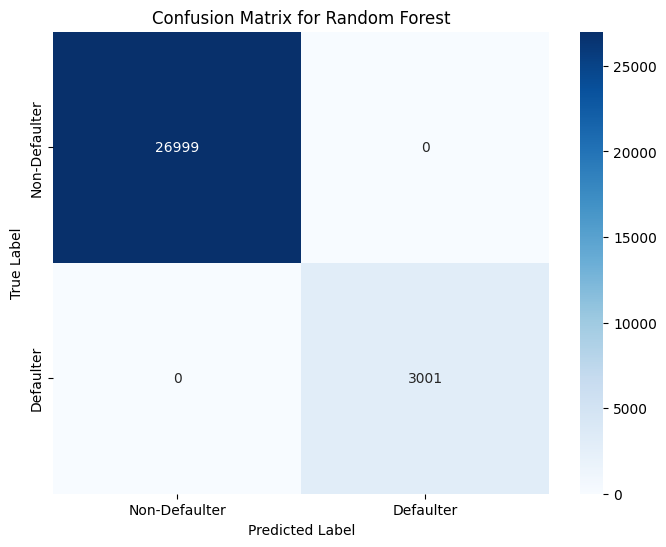


--- Evaluation for Extra Trees ---
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     26999
           1       1.00      1.00      1.00      3001

    accuracy                           1.00     30000
   macro avg       1.00      1.00      1.00     30000
weighted avg       1.00      1.00      1.00     30000

ROC-AUC Score: 1.0000


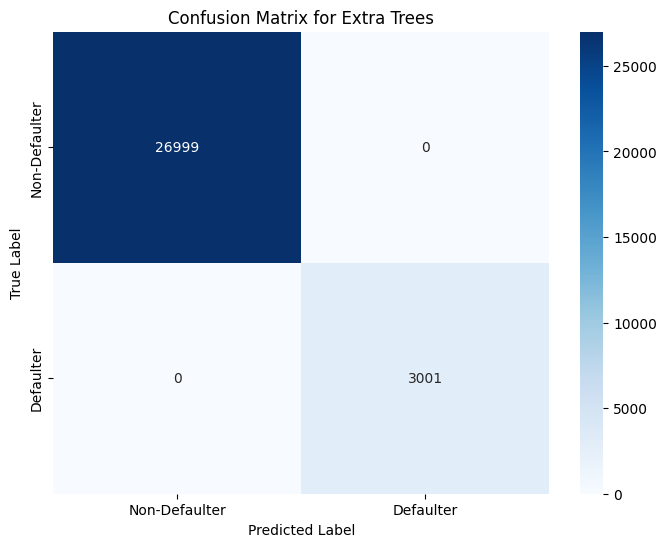


--- Evaluation for Gradient Boosting ---
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     26999
           1       1.00      1.00      1.00      3001

    accuracy                           1.00     30000
   macro avg       1.00      1.00      1.00     30000
weighted avg       1.00      1.00      1.00     30000

ROC-AUC Score: 1.0000


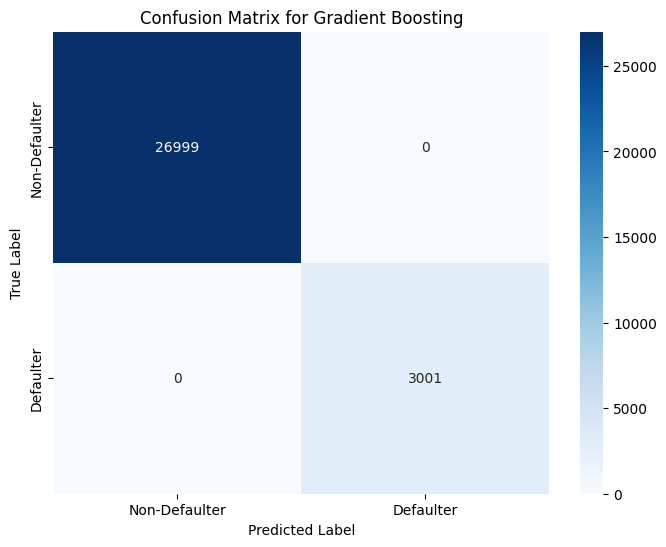


--- Evaluation for K-Nearest Neighbors ---
Classification Report:
              precision    recall  f1-score   support

           0       0.90      1.00      0.95     26999
           1       0.53      0.02      0.04      3001

    accuracy                           0.90     30000
   macro avg       0.71      0.51      0.50     30000
weighted avg       0.86      0.90      0.86     30000

ROC-AUC Score: 0.6610


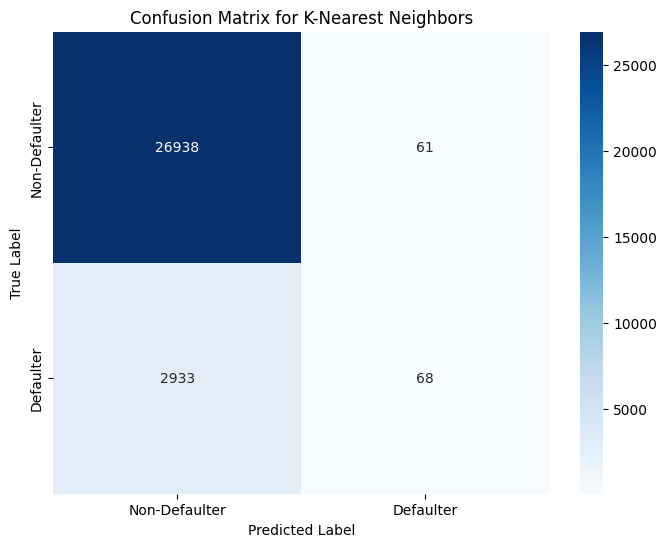


--- Evaluation for Naive Bayes ---
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     26999
           1       1.00      1.00      1.00      3001

    accuracy                           1.00     30000
   macro avg       1.00      1.00      1.00     30000
weighted avg       1.00      1.00      1.00     30000

ROC-AUC Score: 1.0000


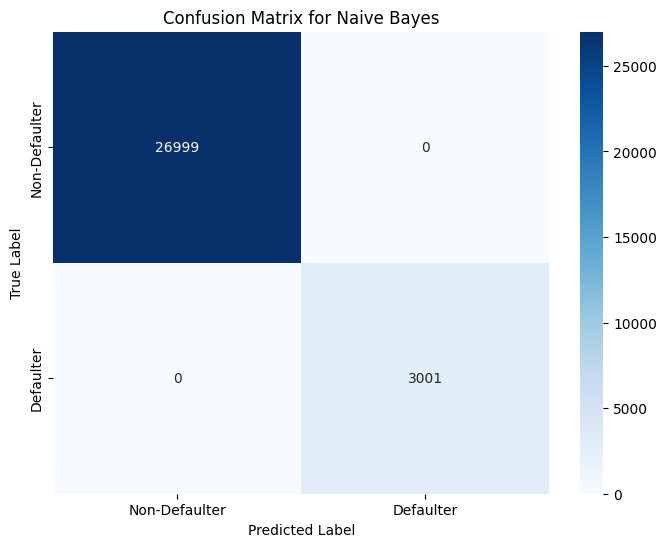


--- Evaluation for XGBoost ---
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     26999
           1       1.00      1.00      1.00      3001

    accuracy                           1.00     30000
   macro avg       1.00      1.00      1.00     30000
weighted avg       1.00      1.00      1.00     30000

ROC-AUC Score: 1.0000


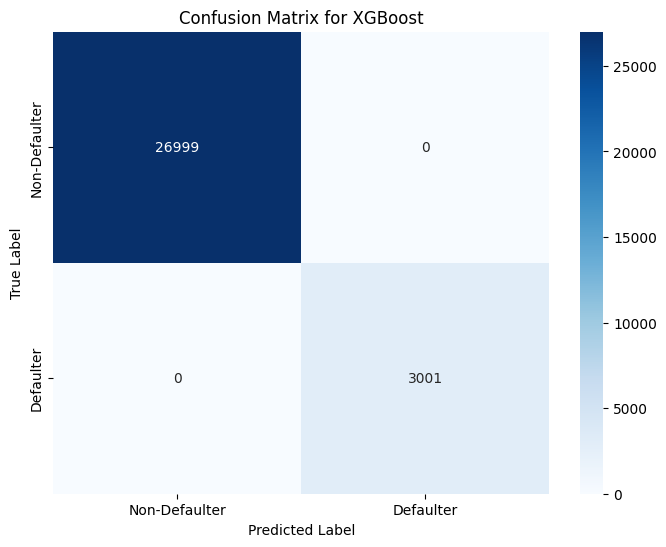


--- Evaluation for LightGBM ---


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     26999
           1       1.00      1.00      1.00      3001

    accuracy                           1.00     30000
   macro avg       1.00      1.00      1.00     30000
weighted avg       1.00      1.00      1.00     30000

ROC-AUC Score: 1.0000


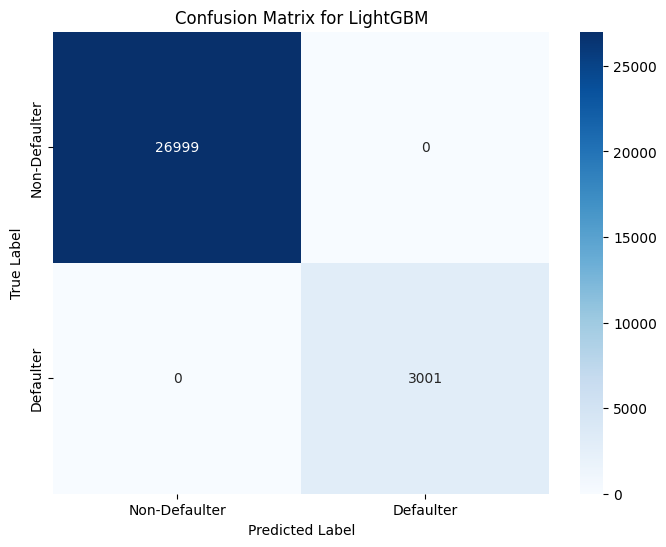

In [24]:
for name, model in models.items():
    print(f"\n--- Evaluation for {name} ---")

    # Make predictions on the test set
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1] # for ROC-AUC

    # Print Classification Report
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    # Print ROC-AUC Score
    auc_score = roc_auc_score(y_test, y_pred_proba)
    print(f"ROC-AUC Score: {auc_score:.4f}")

    # Plot Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Defaulter', 'Defaulter'], yticklabels=['Non-Defaulter', 'Defaulter'])
    plt.title(f'Confusion Matrix for {name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()